# RollingLDA inspection

### Overview

**Input:** outputs from notebook 2.4 (`outputs_rlda_fitting/`)

Pipeline:
1. Setup: load all 2.4 outputs
2. Topic prevalence per year
3. Per-chunk cosine self-similarity (rolling stability diagnostic)
4. Per-topic year-level relevance of words (λ = 0.4)
5. Top-word entry / exit table (topic 0)
6. Relevance heatmap (topic 0)

**Variables:** All quantities are derived from the Gibbs sampler's own `document_sums` matrix, not from re-projecting documents onto `phi`.
* `document_sums` reflects the actual token-topic assignments accumulated during sampling
* `X @ phi.T` is a post-hoc approximation that ignores memory and the rolling update structure.

**Word ranking:** Sections 4–6 rank terms by relevance (Sievert & Shirley 2014) at `LAMBDA_VIS = 0.4`, the same λ used for the static and per-chunk word lists in 2.6 from which the topic labels were derived. Both the topic–word distribution and the background marginal are estimated year-locally. Earlier versions of this notebook ranked by pure lift (λ = 0); lift is still computed and written out alongside for comparison, but relevance is the ranking to report.

## 1. Setup

In [1]:
# Cell 1: Imports
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Cell 2: Paths and column names
CHECKPOINT_DIR = Path("checkpoints")
IN_DIR         = Path("outputs_rlda_fitting")
OUT_DIR        = Path("outputs_rlda_inspection")
OUT_DIR.mkdir(exist_ok=True)

DATE_COL   = "_date"
TOKEN_COL  = "_tokens_filtered"
DOC_ID_COL = "doc_id"

N_TOP_WORDS = 15
LAMBDA_VIS  = 0.4

In [3]:
# Cell 3: Load 2.4 outputs

# Read checkpoint
df = pd.read_pickle(CHECKPOINT_DIR / "df_with_noun_tokens.pkl").copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df[df["noun_tokens"].apply(lambda x: isinstance(x, list))].copy()
df = df.sort_values(DATE_COL).reset_index(drop=True)

with open(CHECKPOINT_DIR / "chosen_vocab.pkl", "rb") as f:
    vc = pickle.load(f)
chosen_vocab_set = set(vc["chosen_vocab"]["kept_terms"])
df[TOKEN_COL] = df["noun_tokens"].apply(
    lambda toks: [t for t in toks if t.lower() in chosen_vocab_set]
)

if DOC_ID_COL not in df.columns:
    df[DOC_ID_COL] = [f"doc_{i}" for i in range(len(df))]

# model arrays
topic_word_counts_df = pd.read_csv(IN_DIR / "rollinglda_final_topic_word_counts.csv")
vocab    = [c for c in topic_word_counts_df.columns if c != "topic_id"]
topics   = topic_word_counts_df[vocab].values
phi      = topics / np.clip(topics.sum(axis=1, keepdims=True), 1e-12, None)
K        = topics.shape[0]

doc_topic_df = pd.read_csv(IN_DIR / "rollinglda_doc_topic.csv")
doc_topic_df[DOC_ID_COL] = doc_topic_df[DOC_ID_COL].astype(str)
df[DOC_ID_COL]           = df[DOC_ID_COL].astype(str)

topic_cols = [f"topic_{k}" for k in range(K)]

# Join on doc_id
df = df.merge(doc_topic_df[[DOC_ID_COL] + topic_cols], on=DOC_ID_COL, how="left")

missing = df[topic_cols].isna().any(axis=1).sum()
if missing > 0:
    raise ValueError(f"{missing} documents have no matching doc_topic row — check doc_id alignment")

doc_topic = df[topic_cols].values

chunks_df = pd.read_csv(IN_DIR / "rollinglda_chunks.csv")

assert len(vocab) == phi.shape[1]
print(f"K={K}, V={len(vocab)}, D={len(df)}")
print(f"Date range: {df[DATE_COL].min().date()} -> {df[DATE_COL].max().date()}")
print(f"Chunks: {len(chunks_df)}")


K=10, V=2871, D=6501
Date range: 1999-09-12 -> 2014-06-12
Chunks: 12


In [4]:
# Cell 4: Shared helpers

vocab_index = {w: i for i, w in enumerate(vocab)}

def get_top_words_per_topic(
    components: np.ndarray,
    feature_names: list,
    n: int = N_TOP_WORDS,
    rel: np.ndarray = None,
) -> pd.DataFrame:
    rows = []
    for idx, topic in enumerate(components):
        top_idx = rel[idx].argsort()[:-n - 1:-1] if rel is not None else topic.argsort()[:-n - 1:-1]
        words   = [feature_names[i] for i in top_idx]
        rows.append({"topic_id": idx, "top_words": ", ".join(words), "top_words_list": words})
    return pd.DataFrame(rows)


def build_bow(frame: pd.DataFrame, tok_col: str, v_index: dict, v_size: int) -> np.ndarray:
    """Build a D x V count matrix from vocab-filtered token lists."""
    X = np.zeros((len(frame), v_size), dtype=np.int32)
    for d, toks in enumerate(frame[tok_col]):
        if not isinstance(toks, list):
            continue
        for tok in toks:
            i = v_index.get(str(tok).lower())
            if i is not None:
                X[d, i] += 1
    return X


def relevance_score(
    phi_k: np.ndarray,
    p_w: np.ndarray,
    lam: float = LAMBDA_VIS,
) -> np.ndarray:
    """Relevance = lambda * log(phi_kw) + (1-lambda) * log(phi_kw / p_w), Sievert & Shirley 2014.

    Identical to the helper in 2.6 so that the temporal rankings here are on the
    same scale as the static and per-chunk rankings used for interpretation.
    Pure lift is the lam=0 special case (the log_phi term drops out entirely),
    which is what this notebook used previously.
    """
    log_phi  = np.log(np.clip(phi_k, 1e-12, None))
    log_lift = log_phi - np.log(np.clip(p_w, 1e-12, None))
    return lam * log_phi + (1 - lam) * log_lift


df["_year"] = df[DATE_COL].dt.year
years = sorted(df["_year"].dropna().unique())
print(f"Years: {years}")

Years: [np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014)]


## 2. Topic prevalence per year

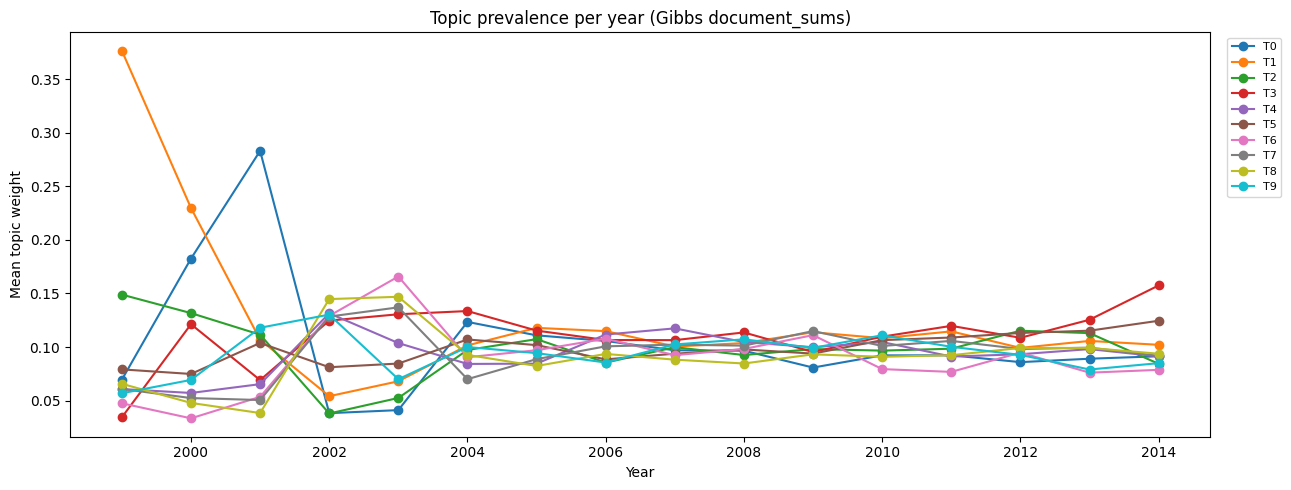

,year,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9
0,1999,0.069478,0.376644,0.148918,0.034353,0.060749,0.079110,0.047457,0.060818,0.065646,0.056828
1,2000,0.182527,0.229803,0.131653,0.121271,0.057094,0.074841,0.033405,0.052330,0.047800,0.069275
2,2001,0.283126,0.106798,0.111534,0.069127,0.065329,0.103794,0.053459,0.050506,0.038340,0.117986
3,2002,0.038236,0.054089,0.037938,0.124661,0.131461,0.081131,0.129050,0.128425,0.144754,0.130254
4,2003,0.041080,0.067992,0.052433,0.130577,0.103674,0.084561,0.165826,0.137026,0.146895,0.069935
5,2004,0.123422,0.101507,0.097241,0.133579,0.084193,0.107042,0.090454,0.069973,0.092614,0.099976
6,2005,0.110907,0.117870,0.107335,0.115323,0.084474,0.101769,0.097030,0.088685,0.082308,0.094299
7,2006,0.105646,0.114856,0.085418,0.106530,0.111634,0.088461,0.107768,0.100636,0.093548,0.085504
8,2007,0.096946,0.100452,0.099835,0.106423,0.117407,0.093768,0.092371,0.102221,0.088177,0.102400
9,2008,0.096563,0.103694,0.092514,0.113607,0.104619,0.097742,0.098189,0.101279,0.084608,0.107184


In [5]:
# Cell 5: Mean topic weight per year

topic_cols = [f"topic_{k}" for k in range(K)]
df_with_topics = pd.concat(
    [df[[DATE_COL, "_year"]].reset_index(drop=True),
     pd.DataFrame(doc_topic, columns=topic_cols)],
    axis=1,
)

# mean θ across all documents
prevalence = (
    df_with_topics.groupby("_year")[topic_cols]
    .mean()
    .reset_index()
    .rename(columns={"_year": "year"})
)

prevalence.to_csv(OUT_DIR / "topic_prevalence_per_year.csv", index=False)

fig, ax = plt.subplots(figsize=(13, 5))
for k in range(K):
    ax.plot(prevalence["year"], prevalence[f"topic_{k}"], marker="o", label=f"T{k}")
ax.set_xlabel("Year")
ax.set_ylabel("Mean topic weight")
ax.set_title("Topic prevalence per year (Gibbs document_sums)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "topic_prevalence_per_year.png", dpi=150)
plt.show()
prevalence

## 3. Per-chunk cosine self-similarity

Note: the final `phi` reflects all chunks, so chunk-level phi is calculated by averaging `doc_topic[chunk_mask].T @ X[chunk_mask]` as the rlda model isnt capable of doing this 

In [6]:
# Cell 6: Build per-chunk expected topic-word distributions
# chunk_phi[c] shape: K x V

def to_date(val):
    return pd.Timestamp("1970-01-01") + pd.Timedelta(days=int(val))


chunks_df["start_dt"] = chunks_df["start.date"].apply(to_date)
chunks_df["end_dt"]   = chunks_df["end.date"].apply(to_date)

X_full = build_bow(df, TOKEN_COL, vocab_index, len(vocab))

chunk_phi = []
chunk_ids = []

for _, row in chunks_df.iterrows():
    mask = (df[DATE_COL] >= row["start_dt"]) & (df[DATE_COL] <= row["end_dt"])
    n_docs = mask.sum()
    if n_docs == 0:
        continue
    # n_docs x K
    theta_c = doc_topic[mask.values] 
    # n_docs x V         
    X_c     = X_full[mask.values]
    # K x V  (expected word counts)           
    tw      = theta_c.T @ X_c                 
    tw_norm = tw / np.clip(tw.sum(axis=1, keepdims=True), 1e-12, None)
    chunk_phi.append(tw_norm)
    chunk_ids.append(int(row["chunk.id"]))

print(f"Built chunk-level phi for {len(chunk_phi)} chunks")

Built chunk-level phi for 12 chunks


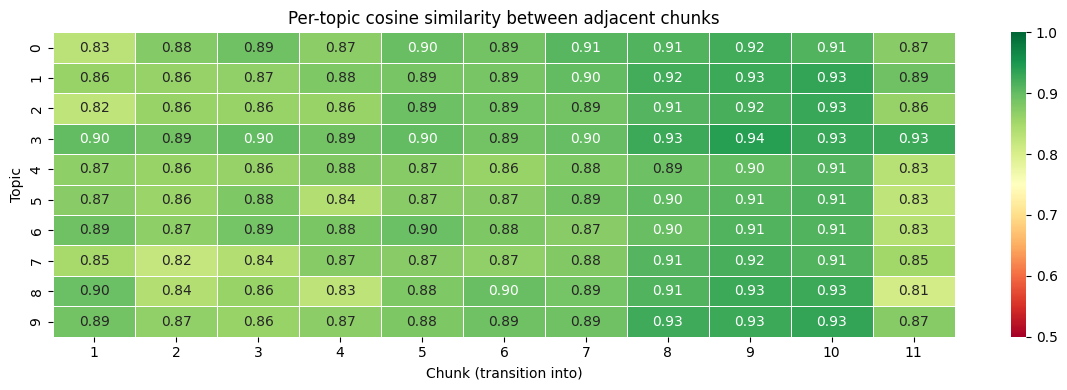


Mean cosine per topic:
topic_id
0    0.889
1    0.892
2    0.882
3    0.908
4    0.875
5    0.876
6    0.886
7    0.872
8    0.878
9    0.892


In [7]:
# Cell 7: Compute per-topic cosine similarity between adjacent chunks

rows = []
for idx in range(1, len(chunk_phi)):
    prev = chunk_phi[idx - 1]   # K x V
    curr = chunk_phi[idx]       # K x V
    for k in range(K):
        sim = float(cosine_similarity(prev[k:k+1], curr[k:k+1])[0, 0])
        rows.append({"chunk_id": chunk_ids[idx], "topic_id": k, "cosine_sim": sim})

cosine_df = pd.DataFrame(rows)
cosine_df.to_csv(OUT_DIR / "chunk_cosine_similarity.csv", index=False)

# Pivot for heatmap
cosine_pivot = cosine_df.pivot(index="topic_id", columns="chunk_id", values="cosine_sim")

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    cosine_pivot, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0.5, vmax=1.0, linewidths=0.4, ax=ax
)
ax.set_title("Per-topic cosine similarity between adjacent chunks")
ax.set_xlabel("Chunk (transition into)")
ax.set_ylabel("Topic")
fig.tight_layout()
fig.savefig(OUT_DIR / "chunk_cosine_similarity_heatmap.png", dpi=150)
plt.show()

print("\nMean cosine per topic:")
print(cosine_df.groupby("topic_id")["cosine_sim"].mean().round(3).to_string())

In [8]:
print(chunks_df[["chunk.id", "n", "n.memory", "n.vocab"]])

    chunk.id    n    n.memory  n.vocab
0          0  936 -2147483648     1671
1          1  236         440     1702
2          2  282         458     1746
3          3  334         518     1804
4          4  421         616     1886
5          5  455         755     1960
6          6  529         876     2078
7          7  596         984     2227
8          8  680        1125     2424
9          9  755        1276     2595
10        10  818        1435     2816
11        11  459        1573     2871


## 4. Per-topic word evolution via year-level relevance (λ = 0.4)

In [9]:
# Cell 8: Year-level relevance using year-specific topic-word distributions
# phi_k,year: expected topic-word usage within the year (theta_y.T @ X_year), normalised
# p_w,year:   background word probability in that year
# Both sides are year-local, mirroring the chunk-local treatment in 2.6.
# Global phi isnt used bc it would mix in information from all other years.
#
# Ranking is by relevance at LAMBDA_VIS (0.4), the same scale used for the static
# and per-chunk word lists that the topic labels were derived from. Previously this
# cell ranked by pure lift, i.e. lambda = 0, which drops the frequency term and so
# favours year-specific rare words over the topic's semantic core.

# year -> K x V relevance array (lambda = LAMBDA_VIS)
year_rel  = {}
# year -> K x V lift array (lambda = 0), retained for comparison only
year_lift = {}
# year -> V word count array (background)
year_bow  = {}
# year -> K x V topic-word dist (year-specific)
year_phi  = {}

for yr in years:
    mask    = df["_year"].values == yr
    X_yr    = X_full[mask]          # n_docs x V
    theta_y = doc_topic[mask]       # n_docs x K

    tw      = theta_y.T @ X_yr     # K x V  expected word counts within year
    tw_norm = tw / np.clip(tw.sum(axis=1, keepdims=True), 1e-12, None)  # K x V dist
    year_phi[yr] = tw_norm

    p_w          = X_yr.sum(axis=0).astype(float)
    year_bow[yr] = p_w
    p_w          = p_w / p_w.sum().clip(min=1e-12)

    year_rel[yr]  = np.vstack([
        relevance_score(tw_norm[k], p_w, lam=LAMBDA_VIS) for k in range(K)
    ])                                                    # K x V
    year_lift[yr] = tw_norm / p_w.clip(min=1e-12)         # K x V

print(f"Year-level relevance (lambda={LAMBDA_VIS}) computed for {len(year_rel)} years")
# Note: early years with few documents will have noisier estimates

Year-level relevance (lambda=0.4) computed for 16 years


In [10]:
# Cell 9: Top relevance words per topic per year
# Both rankings are written out so the lambda=0.4 and lambda=0 lists can be compared
# directly; the relevance column is the one to report.

TOP_WORDS_N = 15

rows = []
for yr in years:
    rel_yr  = year_rel[yr]     # K x V
    lift_yr = year_lift[yr]    # K x V
    for k in range(K):
        rel_idx  = np.argsort(rel_yr[k])[::-1][:TOP_WORDS_N]
        lift_idx = np.argsort(lift_yr[k])[::-1][:TOP_WORDS_N]
        rows.append({
            "year":               yr,
            "topic_id":           k,
            "top_relevance_words": ", ".join(vocab[i] for i in rel_idx),
            "top_relevance_list":  [vocab[i] for i in rel_idx],
            "top_lift_words":      ", ".join(vocab[i] for i in lift_idx),
        })

word_evolution_df = pd.DataFrame(rows)
word_evolution_df[["year", "topic_id", "top_relevance_words", "top_lift_words"]].to_csv(
    OUT_DIR / "topic_word_evolution_relevance.csv", index=False
)

# Quick display: one topic at a time
INSPECT_TOPIC = 0
print(f"\n--- Topic {INSPECT_TOPIC} top relevance words (lambda={LAMBDA_VIS}) by year ---")
for _, row in word_evolution_df[word_evolution_df["topic_id"] == INSPECT_TOPIC].iterrows():
    print(f"  {row['year']}: {row['top_relevance_words']}")


--- Topic 0 top relevance words (lambda=0.4) by year ---
  1999: jolt, closure, smooth, company, thinking, brave, cult, transition, experimental, paper, traditional, brilliant, pleated, simplicity, distressed
  2000: shirt, trouser, leather, skirt, talent, blazer, belt, white, short, suede, tough, moment, jacket, perfect, diverse
  2001: leather, jacket, skirt, trouser, coat, white, blazer, short, boot, sharp, pleated, shirt, belt, button, suit
  2002: suitable, antidote, ensemble, alternative, individual, smoking, leather, streetwear, jacket, darling, ride, precision, apt, pleasing, exercise
  2003: sinuous, jacket, slender, statement, couple, mainstream, mainstay, striking, natty, quest, pull, doubt, strict, skirt, basic
  2004: jacket, skirt, uptown, spring, coat, ninety, handed, leather, case, silk, shirt, white, punky, musical, relief
  2005: coat, skirt, spring, jacket, pantsuit, shirtdress, sleeve, goth, bow, interest, waist, white, leather, pleat, flip
  2006: short, skirt, ja

## 5. Top word entry / exit table

In [ ]:
# Cell 10: Words entering and leaving the top-N relevance set per topic, year over year
# n_churn_lift is reported alongside as the lambda=0 baseline. Under pure lift the
# churn was 19-20 of 20 at every transition, i.e. the set-difference was saturated
# and carried no signal. Compare the two columns before reporting this as drift.

ENTRY_EXIT_N  = 20
ENTRY_EXIT_TOPIC = 0

vocab_arr = np.array(vocab)

def top_set(score_mat, k, n):
    return set(vocab_arr[np.argsort(score_mat[k])[::-1][:n]].tolist())

rel_sets  = {yr: top_set(year_rel[yr],  ENTRY_EXIT_TOPIC, ENTRY_EXIT_N) for yr in years}
lift_sets = {yr: top_set(year_lift[yr], ENTRY_EXIT_TOPIC, ENTRY_EXIT_N) for yr in years}

entry_exit_rows = []
for prev_yr, curr_yr in zip(years[:-1], years[1:]):
    entered = sorted(rel_sets[curr_yr] - rel_sets[prev_yr])
    left    = sorted(rel_sets[prev_yr] - rel_sets[curr_yr])
    entry_exit_rows.append({
        "transition":    f"{prev_yr}→{curr_yr}",
        "entered":       ", ".join(entered),
        "left":          ", ".join(left),
        "n_entered":     len(entered),
        "n_left":        len(left),
        "n_churn_lift":  len(lift_sets[curr_yr] - lift_sets[prev_yr]),
    })
    print(f"\n{prev_yr} → {curr_yr}  (relevance churn {len(entered)}/{ENTRY_EXIT_N}, "
          f"lift churn {len(lift_sets[curr_yr] - lift_sets[prev_yr])}/{ENTRY_EXIT_N})")
    print(f"  Entered: {entered}")
    print(f"  Left:    {left}")

entry_exit_df = pd.DataFrame(entry_exit_rows)
entry_exit_df.to_csv(OUT_DIR / f"entry_exit_relevance_topic{ENTRY_EXIT_TOPIC}.csv", index=False)


1999 → 2000  (relevance churn 20/20, lift churn 20/20)
  Entered: ['belt', 'blazer', 'cord', 'diverse', 'jacket', 'leather', 'moment', 'perfect', 'sensational', 'shirt', 'short', 'skirt', 'straight', 'strap', 'suede', 'talent', 'tough', 'trouser', 'wearable', 'white']
  Left:    ['brave', 'brilliant', 'closure', 'company', 'crinkly', 'cult', 'desire', 'distressed', 'experimental', 'jolt', 'notion', 'one', 'paper', 'pleated', 'simplicity', 'smooth', 'thinking', 'traditional', 'transition', 'worth']

2000 → 2001  (relevance churn 10/20, lift churn 20/20)
  Entered: ['boot', 'button', 'coat', 'couple', 'fur', 'nonsense', 'pleated', 'sharp', 'sleeve', 'suit']
  Left:    ['cord', 'diverse', 'moment', 'perfect', 'sensational', 'straight', 'suede', 'talent', 'tough', 'wearable']

2001 → 2002  (relevance churn 17/20, lift churn 20/20)
  Entered: ['alternative', 'antidote', 'apt', 'closet', 'darling', 'ensemble', 'exercise', 'hooded', 'individual', 'pleasing', 'precision', 'ride', 'smoking', '